# Supervised Learning - Naive bayes 

<h5 style="font-size:14px;">

<b>Definition:</b> Naive Bayes is a supervised machine learning classification algorithm based on Bayes' Theorem. It is a probabilistic model that estimates the probability of a sample belonging to a specific class, assuming conditional independence between input features. The algorithm can be used for both binary and multiclass classification problems.

<b>Types of Naive Bayes:</b><br>
- <b>Gaussian Naive Bayes</b> – used for continuous data, assuming that features follow a normal (Gaussian) distribution.<br>
- <b>Multinomial Naive Bayes</b> – commonly used in text classification based on frequency counts.<br>
- <b>Bernoulli Naive Bayes</b> – used for binary features (0/1 values).

<b>Theoretical Basis:</b><br>
The algorithm is based on <b>Bayes' Theorem</b>:

<br>
P(C|X) = (P(X|C) · P(C)) / P(X)

<br>
Where:<br>
- P(C|X) – posterior probability of class C given feature vector X.<br>
- P(X|C) – likelihood, the probability of observing data X given class C.<br>
- P(C) – prior probability of class C.<br>
- P(X) – marginal probability of the data (constant for classification).

<b>Main Assumption:</b><br>
The algorithm assumes conditional independence between input features given the class label.

<b>Advantages:</b><br>
- Computational simplicity.<br>
- Works well with large datasets.<br>
- Fast training process.

<b>Limitations:</b><br>
- The independence assumption is often unrealistic in real-world data.<br>
- Performance may decrease if feature distributions do not match the assumed model.

</h5>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB

## Dataset Description – Breast Cancer Dataset

The dataset used in this project comes from the Kaggle platform and contains information about patients diagnosed with breast cancer. The objective is to classify the patient’s status based on clinical and tumor-related characteristics.

### Demographic and Clinical Features

- **Age** – the age of the patient.
- **Race** – the patient's race (e.g., White, Other).
- **Marital Status** – the patient's marital status (e.g., Married, Single).
- **T Stage** – classification of the primary tumor according to its size and extent.
- **N Stage** – indicates whether lymph nodes are affected.
- **6th Stage** – the clinical stage of the cancer according to medical classification.
- **Differentiate** – the degree of cellular differentiation, which shows how much the tumor cells resemble normal cells.

- **Grade** – the histological grade of the tumor, indicating the aggressiveness of the cancer:
  - Grade 1 – less aggressive tumor
  - Grade 2 – moderately aggressive tumor
  - Grade 3 – highly aggressive tumor

- **A Stage** – shows the extent of the neoplasm:
  - Regional – local spread
  - Distant – metastasis to distant organs

- **Tumor Size** – the size of the tumor measured in millimeters.
- **Estrogen Status** – indicates the presence or absence of estrogen receptors.
- **Progesterone Status** – indicates the status of progesterone receptors.
- **Regional Node Examined** – the number of lymph nodes examined.
- **Regional Node Positive** – the number of lymph nodes with confirmed metastasis.

### Target Variable

- **Status** – the variable to be classified:
  - Alive
  - Dead
  

In [3]:
data = pd.read_csv("../data/Breast_Cancer.csv")

In [4]:
data.head(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
5,51,White,Single,T1,N1,IIA,Moderately differentiated,2,Regional,20,Positive,Positive,18,2,89,Alive
6,51,White,Married,T1,N1,IIA,Well differentiated,1,Regional,8,Positive,Positive,11,1,54,Alive
7,40,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,9,1,14,Dead
8,40,White,Divorced,T4,N3,IIIC,Poorly differentiated,3,Regional,103,Positive,Positive,20,18,70,Alive
9,69,White,Married,T4,N3,IIIC,Well differentiated,1,Distant,32,Positive,Positive,21,12,92,Alive


In [5]:
data.tail(10)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
4014,40,White,Married,T3,N1,IIIA,Moderately differentiated,2,Regional,68,Positive,Positive,22,2,86,Alive
4015,65,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,40,Positive,Positive,4,4,68,Alive
4016,54,White,Married,T2,N1,IIB,Well differentiated,1,Regional,50,Positive,Positive,29,2,52,Alive
4017,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,28,Negative,Negative,2,1,19,Dead
4018,64,White,Married,T1,N1,IIA,Moderately differentiated,2,Regional,10,Positive,Positive,11,1,70,Alive
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive
4023,46,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,30,Positive,Positive,7,2,100,Alive


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Reginol Node Positive   4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status                  4024 non

In [7]:
data.describe()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [8]:
data.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='str')

In [9]:
data.shape

(4024, 16)

In [10]:
data.dtypes

Age                       int64
Race                        str
Marital Status              str
T Stage                     str
N Stage                     str
6th Stage                   str
differentiate               str
Grade                       str
A Stage                     str
Tumor Size                int64
Estrogen Status             str
Progesterone Status         str
Regional Node Examined    int64
Reginol Node Positive     int64
Survival Months           int64
Status                      str
dtype: object

In [11]:
data.isnull().sum()

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(1)

In [13]:
data.nunique()

Age                        40
Race                        3
Marital Status              5
T Stage                     4
N Stage                     3
6th Stage                   5
differentiate               4
Grade                       4
A Stage                     2
Tumor Size                110
Estrogen Status             2
Progesterone Status         2
Regional Node Examined     54
Reginol Node Positive      38
Survival Months           107
Status                      2
dtype: int64

<Axes: >

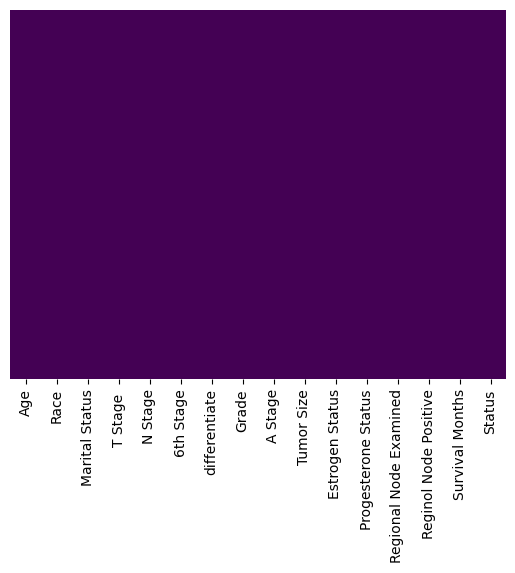

In [14]:
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [15]:
data = pd.read_csv("../data/Breast_Cancer.csv")

categorical_cols = [
    'Race', 'Marital Status', 'T Stage ', 'N Stage',
    '6th Stage', 'differentiate', 'Grade', 'A Stage',
    'Estrogen Status', 'Progesterone Status', 'Status'
]

le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [16]:
data.head(5)

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,2,1,0,0,0,1,3,1,4,1,1,24,1,60,0
1,50,2,1,1,1,2,0,2,1,35,1,1,14,5,62,0
2,58,2,0,2,2,4,0,2,1,63,1,1,14,7,75,0
3,58,2,1,0,0,0,1,3,1,18,1,1,2,1,84,0
4,47,2,1,1,0,1,1,3,1,41,1,1,3,1,50,0


In [17]:
print(data.columns.tolist())

['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage', 'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status', 'Progesterone Status', 'Regional Node Examined', 'Reginol Node Positive', 'Survival Months', 'Status']


In [18]:
categorical_cols = data.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [ ]:
X = data.drop("Status", axis = 1)
y = data["Status"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [22]:
y_pred = model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8397515527950311


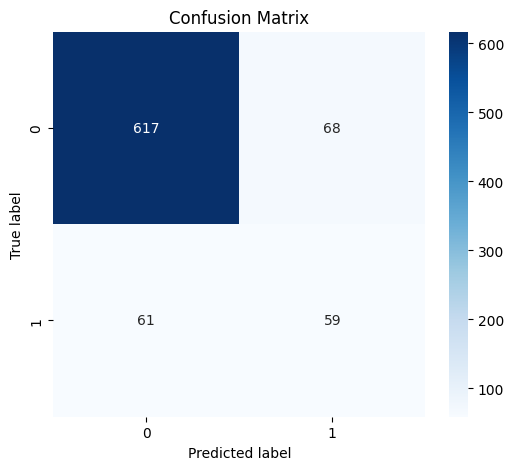

In [28]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       685
           1       0.46      0.49      0.48       120

    accuracy                           0.84       805
   macro avg       0.69      0.70      0.69       805
weighted avg       0.84      0.84      0.84       805



In [26]:
new_patient = [
    45,   # Age
    0,    # Race (ex: White → 0 după LabelEncoder)
    1,    # Marital Status (ex: Married → 1)
    2,    # T Stage
    1,    # N Stage
    2,    # 6th Stage
    1,    # differentiate
    2,    # Grade
    0,    # A Stage (Regional → 0)
    35,   # Tumor Size (mm)
    1,    # Estrogen Status (Positive → 1)
    1,    # Progesterone Status (Positive → 1)
    5,    # Regional Node Examined
    2,    # Reginol Node Positive
    60    # Survival Months
]

In [27]:
new_patient_df = pd.DataFrame([new_patient], columns=X.columns)

prediction = model.predict(new_patient_df)
probability = model.predict_proba(new_patient_df)

if prediction[0] == 1:
    print("\nResult: MALIGNANT tumor")
else:
    print("\nResult: BENIGN tumor")

print("Probabilities:", probability)


Result: MALIGNANT tumor
Probabilities: [[3.92860560e-09 9.99999996e-01]]
